Write Python code for reading and visualizing the time series data contained in the
files A1_Training, A1_Validation.txt, and A1_Test.txt

In [ ]:
import csv
import numpy as np 

training = []
validation = []
testing = []


with open('A1_training.txt') as training_file:
    plotting = csv.reader(training_file, delimiter='\t')

    for row in plotting:
        training.append(float(row[0]))

with open('A1_validation.txt') as validation_file:
    plotting = csv.reader(validation_file, delimiter='\t')

    for row in plotting:
        validation.append(float(row[0]))

with open('A1_test.txt') as test_file:
    plotting = csv.reader(test_file, delimiter='\t')

    for row in plotting:
        testing.append(float(row[0]))

training_file.close()
validation_file.close()
test_file.close()

training = np.array(training)
validation = np.array(validation)
testing = np.array(testing)


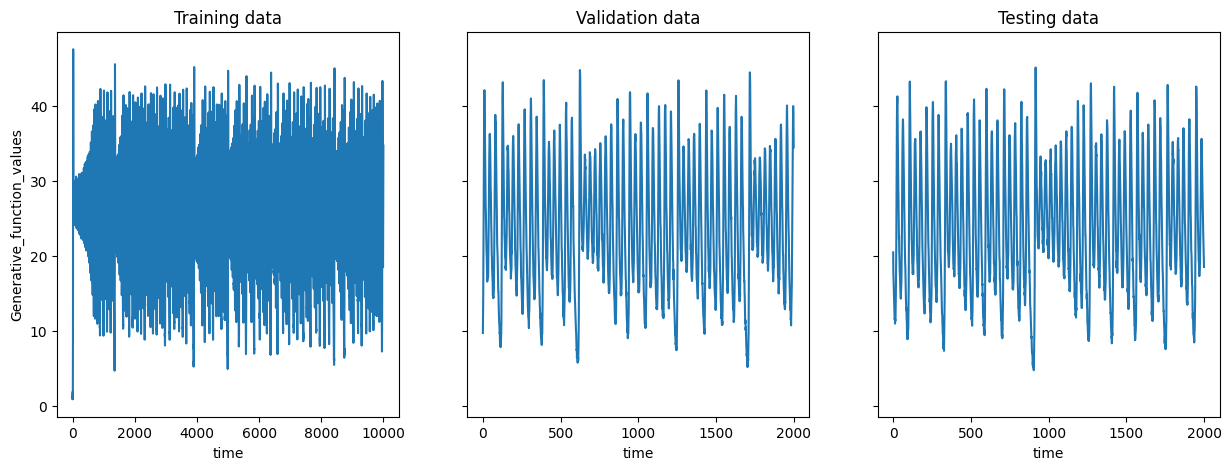

In [17]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axs[0].plot(training)

axs[0].set_ylabel('Generative_function_values')
axs[0].set_xlabel('time')
axs[0].set_title("Training data")


axs[1].plot(validation)
#axs[1].set_ylabel('Generative_function_values')
axs[1].set_xlabel('time')
axs[1].set_title("Validation data")

axs[2].plot(testing)
#axs[2].set_ylabel('Generative_function_values')
axs[2].set_xlabel('time')
axs[2].set_title("Testing data")

plt.show()

Fit ARMA model to training data. 
Use Nelder-Mead approach (in scipy.iptimize, set method to Nelder-Mead)
Output: plot showing the test data series and fit that was obtained from ARMA model over that set.
RMSE should be printed (as text)

One method (arma_inference) for making predictions and
one for computing loss function (arma_loss)
use res = minimize(arma_loss, np.zeros(p+q), method='Nelder-Mead', tol=1e-4)

In [21]:
from scipy.optimize import minimize

def arma_loss(params, p, q, training):

    phi = params[1:p+1]
    theta = params[p+1:p+q+1]
    c = params[0]
    
    predicted = np.zeros_like(training)
    error = np.zeros_like(training)

    for t in range(max(p,q), len(training)):
        next = c
        for i in range(len(phi)):
            next += phi[i] * training[t - i - 1]
        for j in range(len(theta)):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next
        error[t] = training[t] - predicted[t]
    
    return np.mean((training[max(p, q):] - predicted[max(p, q):]) ** 2)


def arma_predict(training, p, q):


    res = minimize(arma_loss, np.zeros(p+q+1), args = (p, q, training), method='Nelder-Mead', tol=1e-4)

    return(res)

p = 2
q = 2


res = arma_predict(training, p, q)
print(res)

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 1.9205390802678977
             x: [-4.900e-01  5.976e-01  4.185e-01  3.995e-01  5.311e-01]
           nit: 103
          nfev: 186
 final_simplex: (array([[-4.900e-01,  5.976e-01, ...,  3.995e-01,
                         5.311e-01],
                       [-4.899e-01,  5.975e-01, ...,  3.994e-01,
                         5.310e-01],
                       ...,
                       [-4.900e-01,  5.976e-01, ...,  3.995e-01,
                         5.311e-01],
                       [-4.899e-01,  5.975e-01, ...,  3.994e-01,
                         5.310e-01]], shape=(6, 5)), array([ 1.921e+00,  1.921e+00,  1.921e+00,  1.921e+00,
                        1.921e+00,  1.921e+00]))


Graph

RMSE: 2.565287958138807


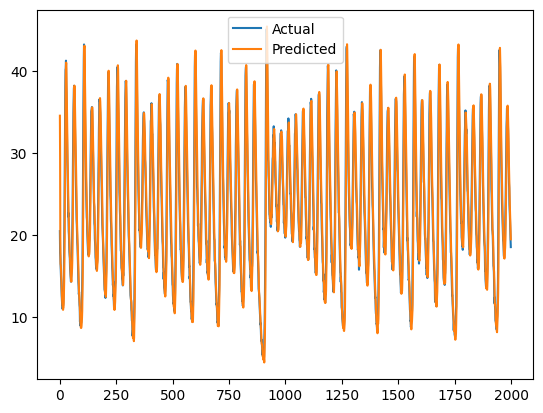

In [23]:
def arma_calculation(params, p, q, length, training, testing):

    phi = params[1:p+1]
    theta = params[p+1:p+q+1]
    c = params[0]
    
    predicted = np.zeros(length)
    #error = np.zeros_like(training)
    error = np.zeros(length)
    #predicted[:max(p, q)] = training[-max(p, q):]

    history = list(training[-max(p, q):])

    for t in range(length):
        next = c
        for i in range(p):
            next += phi[i] * history[- i - 1]
        for j in range(q):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next

        error[t] = testing[t] - predicted[t]

        history.append(predicted[t])
    
    return predicted


results = arma_calculation(res.x, p, q, len(testing), training, testing)


rmse = np.sqrt(np.mean((testing - results) ** 2))
print("RMSE:", rmse)
plt.plot(testing, label='Actual')
plt.plot(results, label='Predicted')
plt.legend()
plt.show()